<h1>![Screenshot 2024-01-08 152247.png](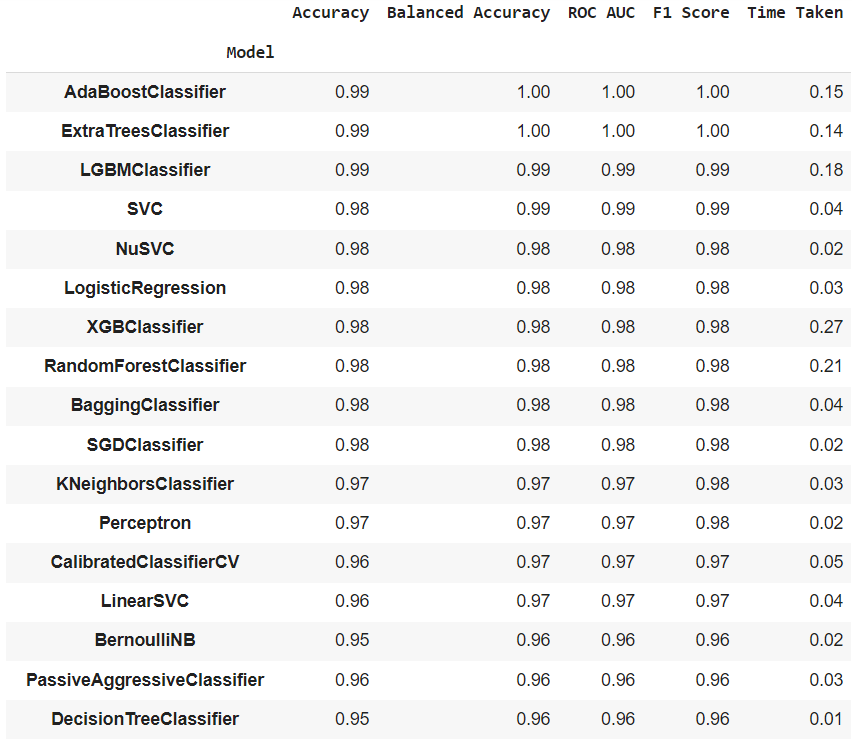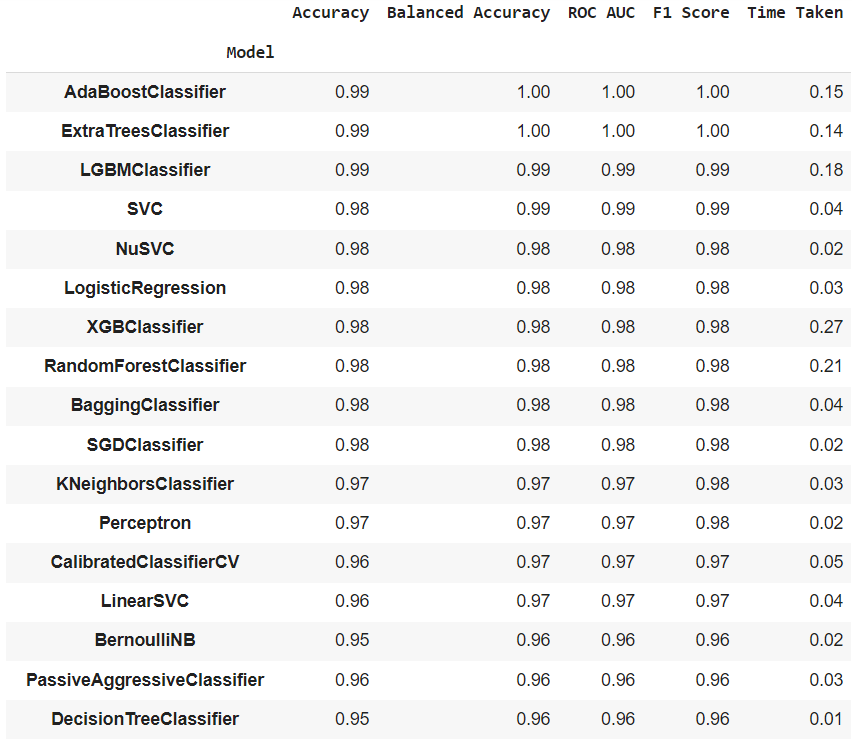)Chronic Kidney Disease Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')


In [2]:
# loading data
from sklearn.datasets import fetch_openml

data = fetch_openml(name='chronic-kidney-disease', version=2, parser="auto")


In [3]:
df = pd.DataFrame(data=data.data,
                  columns=data.feature_names)

df["class"] =data.target

print(df.head())
k=df.columns
k

     Bp     Sg   Al   Su  Rbc    Bu   Sc     Sod   Pot  Hemo    Wbcc  Rbcc  \
0  80.0  1.020  1.0  0.0  1.0  36.0  1.2  137.53  4.63  15.4  7800.0  5.20   
1  50.0  1.020  4.0  0.0  1.0  18.0  0.8  137.53  4.63  11.3  6000.0  4.71   
2  80.0  1.010  2.0  3.0  1.0  53.0  1.8  137.53  4.63   9.6  7500.0  4.71   
3  70.0  1.005  4.0  0.0  1.0  56.0  3.8  111.00  2.50  11.2  6700.0  3.90   
4  80.0  1.010  2.0  0.0  1.0  26.0  1.4  137.53  4.63  11.6  7300.0  4.60   

   Htn  class  
0  1.0    1.0  
1  0.0    1.0  
2  0.0    1.0  
3  1.0    1.0  
4  0.0    1.0  


Index(['Bp', 'Sg', 'Al', 'Su', 'Rbc', 'Bu', 'Sc', 'Sod', 'Pot', 'Hemo', 'Wbcc',
       'Rbcc', 'Htn', 'class'],
      dtype='object')

In [4]:
df.columns

Index(['Bp', 'Sg', 'Al', 'Su', 'Rbc', 'Bu', 'Sc', 'Sod', 'Pot', 'Hemo', 'Wbcc',
       'Rbcc', 'Htn', 'class'],
      dtype='object')

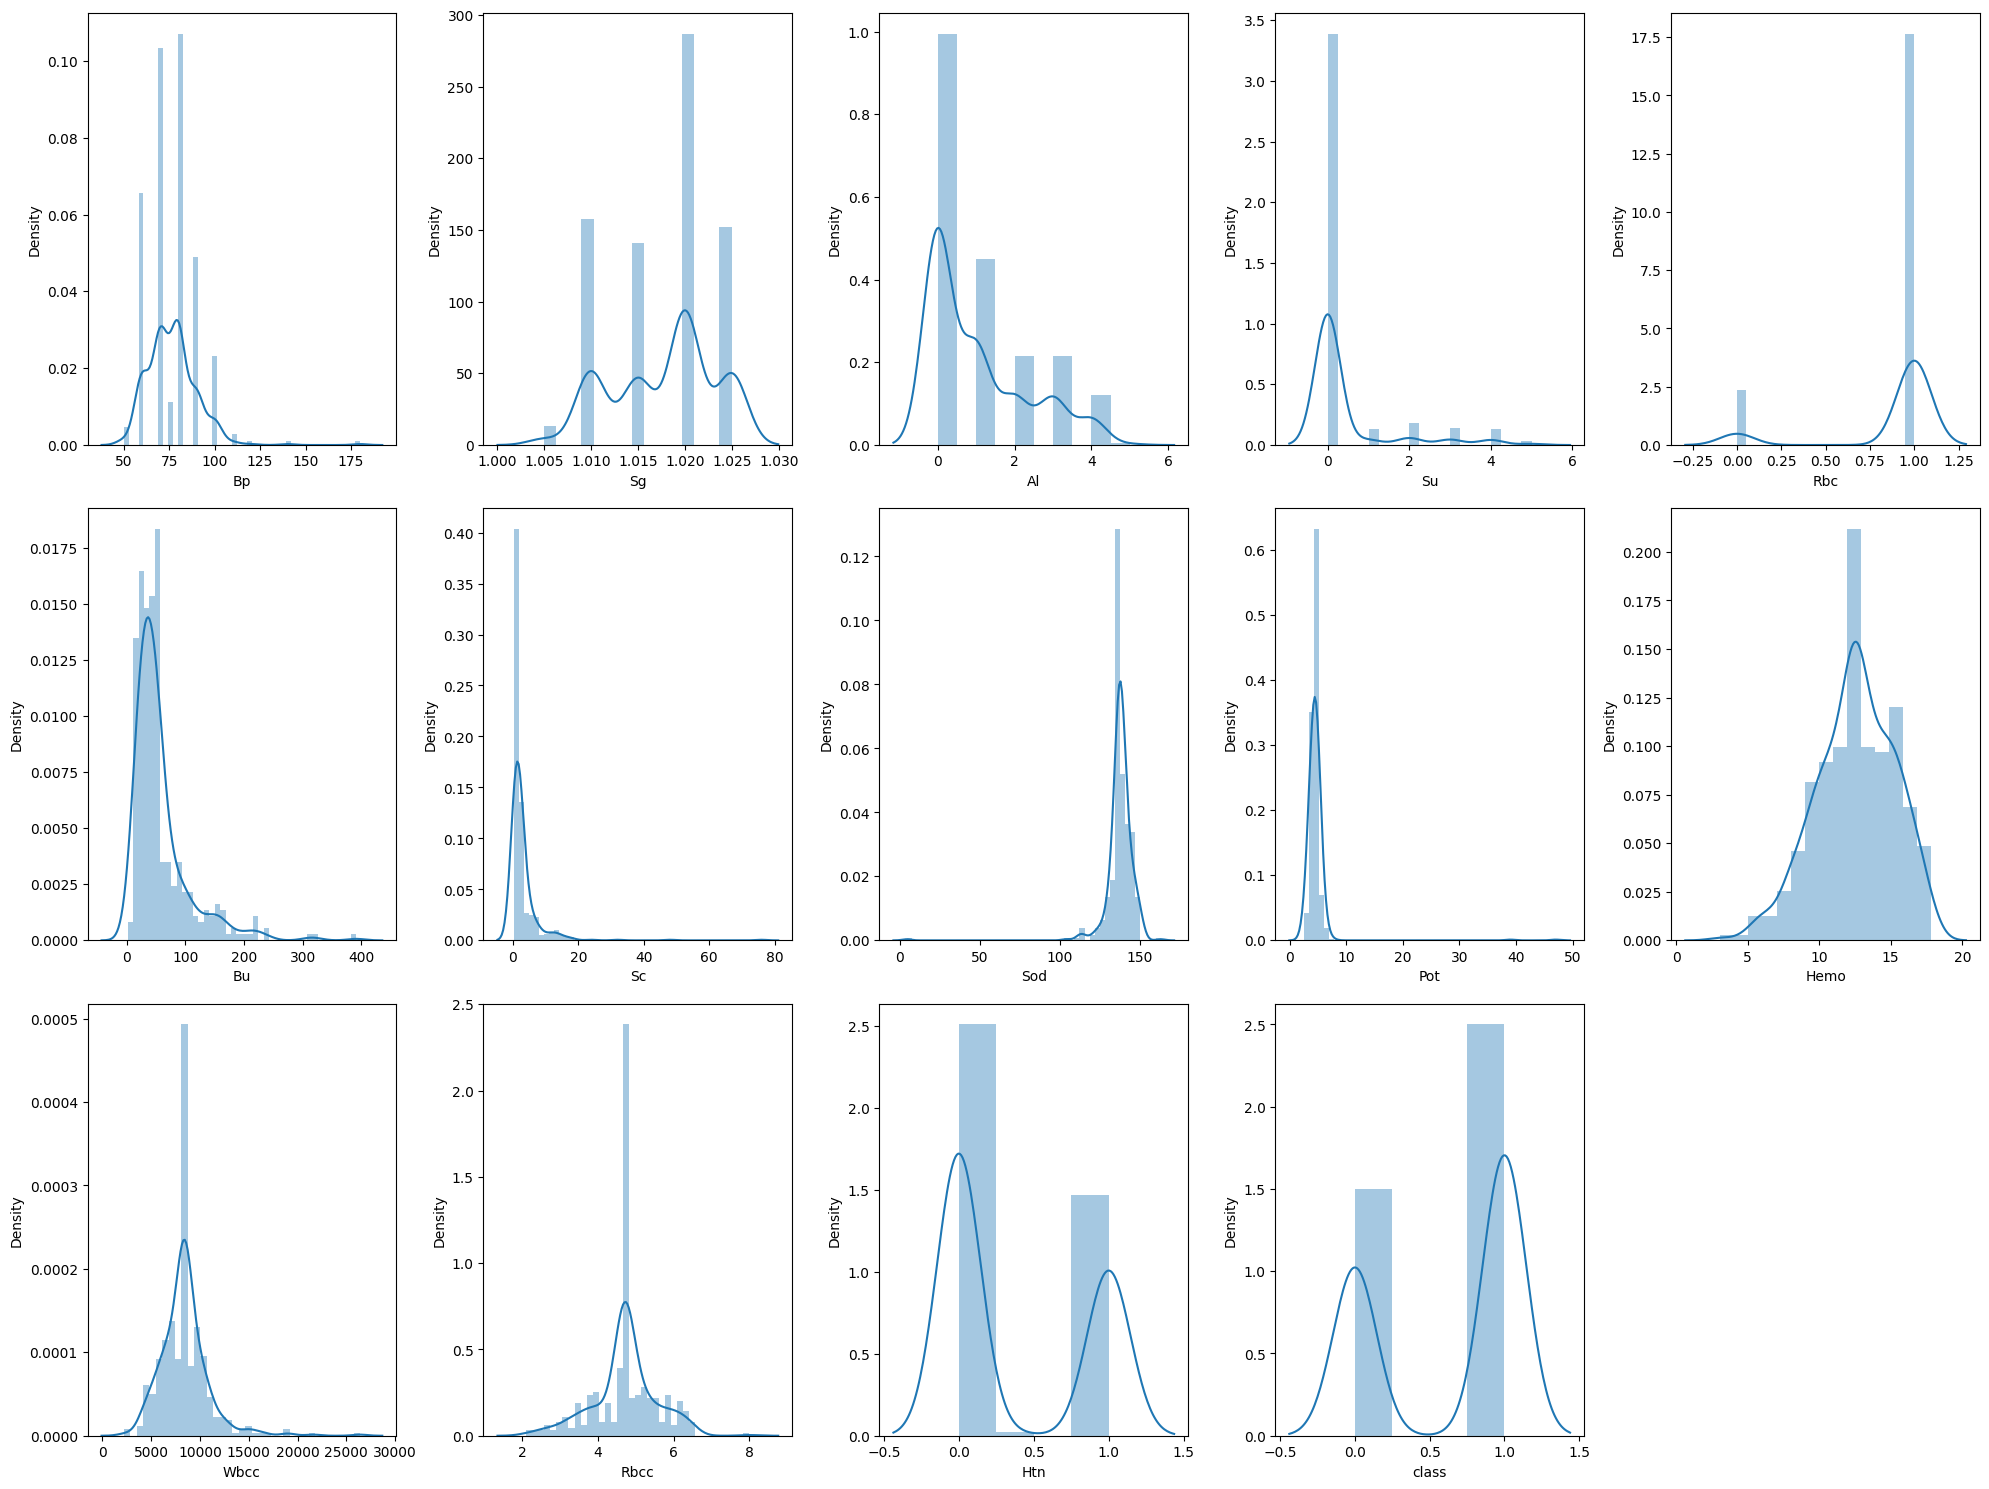

In [5]:
# checking numerical features distribution

plt.figure(figsize = (20, 15))
plotnumber = 1

for column in k:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column)

    plotnumber += 1

plt.tight_layout()
plt.show()

In [6]:
df.shape

(400, 14)

In [7]:
# rename column names to make it more user-friendly

df.columns = ['Blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'white_blood_cell_count', 'red_blood_cell_count', 'hypertension', 'class']
k=['Blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'white_blood_cell_count', 'red_blood_cell_count', 'hypertension']

In [8]:
df.head()

,Blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,white_blood_cell_count,red_blood_cell_count,hypertension,class
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1.0
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1.0
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1.0
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1.0
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1.0


In [9]:
df.describe()

,Blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,white_blood_cell_count,red_blood_cell_count,hypertension,class
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,76.455000,1.017712,1.015000,0.395000,0.882500,57.40550,3.07235,137.529025,4.627850,12.526900,8406.090000,4.708275,0.369350,0.625000
std,13.476536,0.005434,1.272329,1.040038,0.322418,49.28597,5.61749,9.204273,2.819783,2.716171,2523.219976,0.840315,0.482023,0.484729
min,50.000000,1.005000,0.000000,0.000000,0.000000,1.50000,0.40000,4.500000,2.500000,3.100000,2200.000000,2.100000,0.000000,0.000000
25%,70.000000,1.015000,0.000000,0.000000,1.000000,27.00000,0.90000,135.000000,4.000000,10.875000,6975.000000,4.500000,0.000000,0.000000
50%,78.000000,1.020000,1.000000,0.000000,1.000000,44.00000,1.40000,137.530000,4.630000,12.530000,8406.000000,4.710000,0.000000,1.000000
75%,80.000000,1.020000,2.000000,0.000000,1.000000,61.75000,3.07000,141.000000,4.800000,14.625000,9400.000000,5.100000,1.000000,1.000000
max,180.000000,1.025000,5.000000,5.000000,1.000000,391.00000,76.00000,163.000000,47.000000,17.800000,26400.000000,8.000000,1.000000,1.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Blood_pressure          400 non-null    float64
 1   specific_gravity        400 non-null    float64
 2   albumin                 400 non-null    float64
 3   sugar                   400 non-null    float64
 4   red_blood_cells         400 non-null    float64
 5   blood_urea              400 non-null    float64
 6   serum_creatinine        400 non-null    float64
 7   sodium                  400 non-null    float64
 8   potassium               400 non-null    float64
 9   haemoglobin             400 non-null    float64
 10  white_blood_cell_count  400 non-null    float64
 11  red_blood_cell_count    400 non-null    float64
 12  hypertension            400 non-null    float64
 13  class                   400 non-null    float64
dtypes: float64(14)
memory usage: 43.9 KB


In [11]:
# looking at unique values in categorical columns

for col in df.columns:
    print(f"{col} has {df[col].unique()} values\n")

Blood_pressure has [ 80.  50.  70.  90.  76. 100.  60. 110. 140. 180. 120.] values

specific_gravity has [1.02  1.01  1.005 1.015 1.025] values

albumin has [1. 4. 2. 3. 0. 5.] values

sugar has [0. 3. 4. 1. 2. 5.] values

red_blood_cells has [1. 0.] values

blood_urea has [ 36.   18.   53.   56.   26.   25.   54.   31.   60.  107.   55.   72.
  86.   90.  162.   46.   87.   27.  148.  180.  163.   57.   50.   75.
  45.   28.  155.   33.   39.  153.   29.   65.  103.   70.   80.   20.
 202.   77.   89.   24.   17.   32.  114.   66.   38.  164.  142.   96.
 391.   15.  111.   73.   19.   92.   35.   16.  139.   48.   85.   98.
 186.   37.   47.   52.   82.   51.  106.   22.  217.   88.  118.   50.1
  71.   34.   40.   21.  219.   30.  125.  166.   49.  208.  176.   68.
 145.  165.  322.   23.  235.  132.   76.   42.   44.   41.  113.    1.5
 146.   58.  133.  137.   67.  115.  223.   98.6 158.   94.   74.  150.
  61.   95.  191.   93.  241.   64.   79.  215.  309.   10. ] values

serum_

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Blood_pressure          400 non-null    float64
 1   specific_gravity        400 non-null    float64
 2   albumin                 400 non-null    float64
 3   sugar                   400 non-null    float64
 4   red_blood_cells         400 non-null    float64
 5   blood_urea              400 non-null    float64
 6   serum_creatinine        400 non-null    float64
 7   sodium                  400 non-null    float64
 8   potassium               400 non-null    float64
 9   haemoglobin             400 non-null    float64
 10  white_blood_cell_count  400 non-null    float64
 11  red_blood_cell_count    400 non-null    float64
 12  hypertension            400 non-null    float64
 13  class                   400 non-null    float64
dtypes: float64(14)
memory usage: 43.9 KB


In [13]:
df.columns

Index(['Blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'white_blood_cell_count',
       'red_blood_cell_count', 'hypertension', 'class'],
      dtype='object')

<Axes: xlabel='Blood_pressure', ylabel='count'>

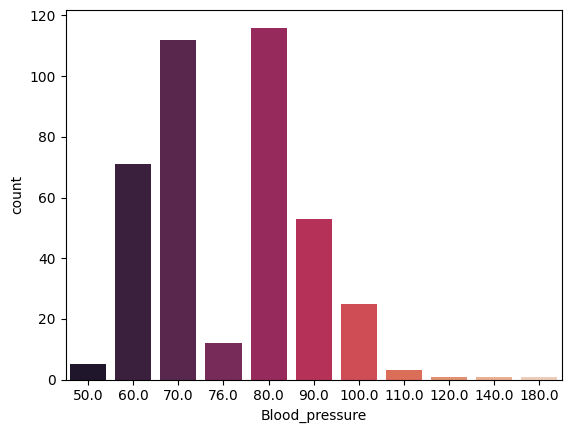

In [14]:
sns.countplot(df, x='Blood_pressure',palette='rocket')

<Axes: xlabel='specific_gravity', ylabel='count'>

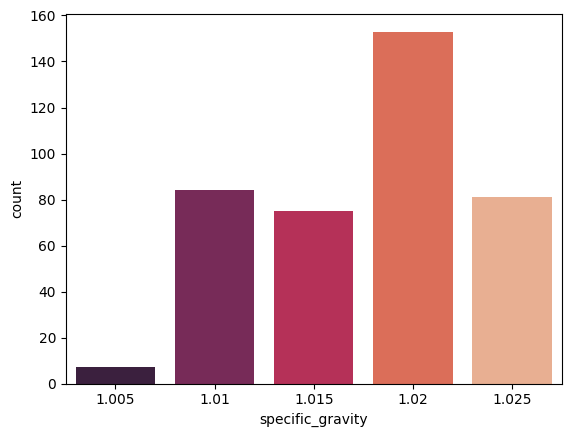

In [15]:
sns.countplot(df, x='specific_gravity',palette='rocket')

<Axes: xlabel='albumin', ylabel='count'>

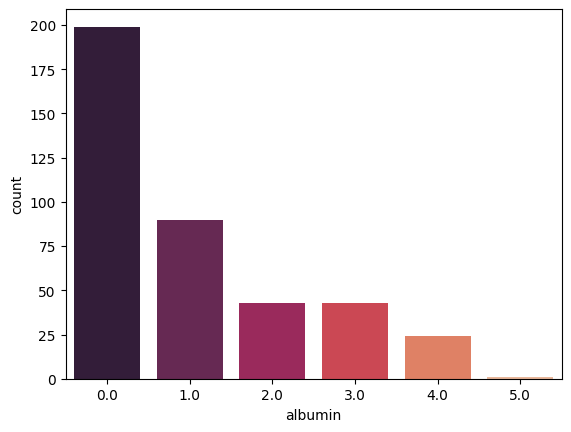

In [16]:
sns.countplot(df, x='albumin',palette='rocket')

<Axes: xlabel='sugar', ylabel='count'>

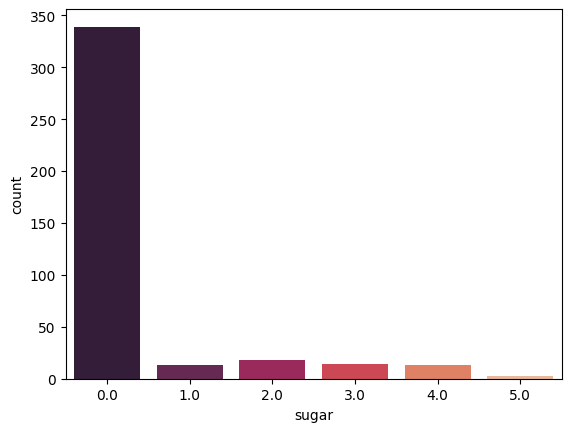

In [17]:
sns.countplot(df, x='sugar',palette='rocket')

<Axes: xlabel='red_blood_cells', ylabel='count'>

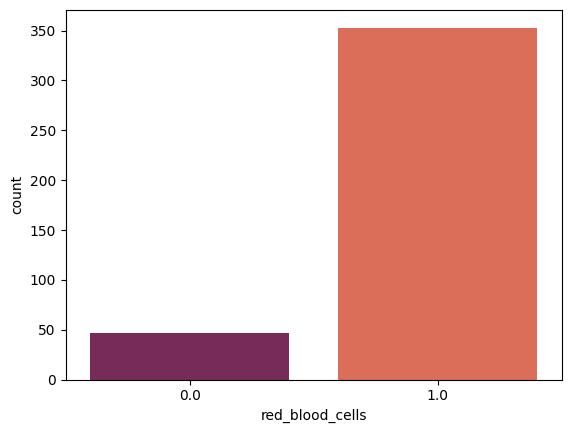

In [18]:
sns.countplot(df, x='red_blood_cells',palette='rocket')

<Axes: xlabel='count', ylabel='blood_urea'>

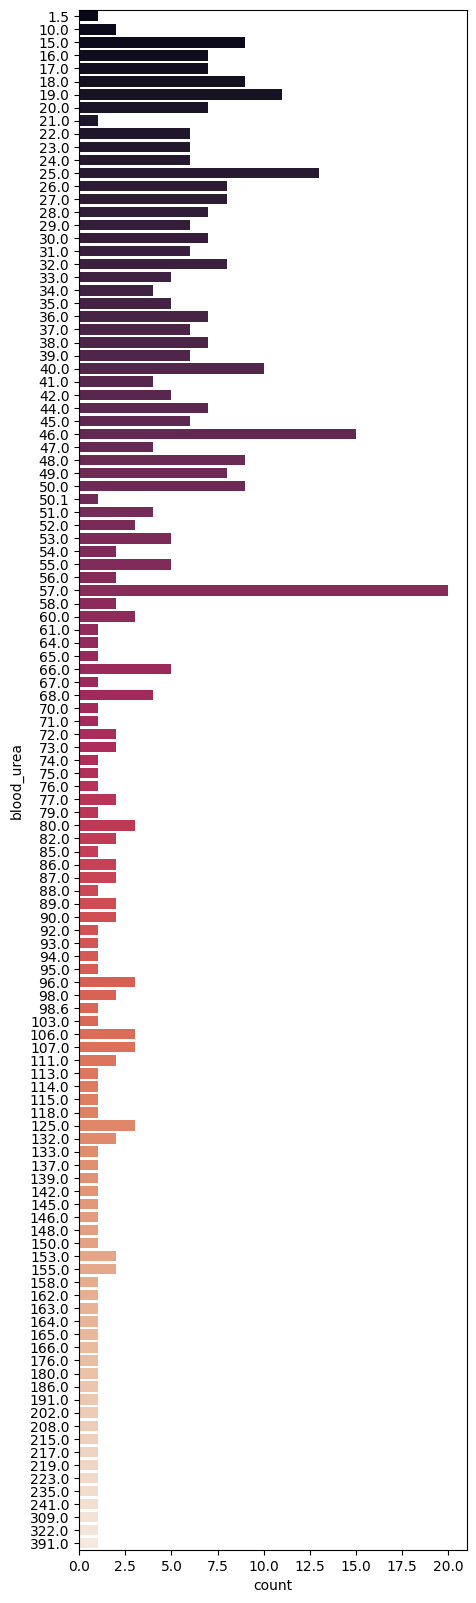

In [49]:
plt.figure(figsize=(5,20))
sns.countplot(df, y='blood_urea',palette='rocket')

<Axes: xlabel='count', ylabel='serum_creatinine'>

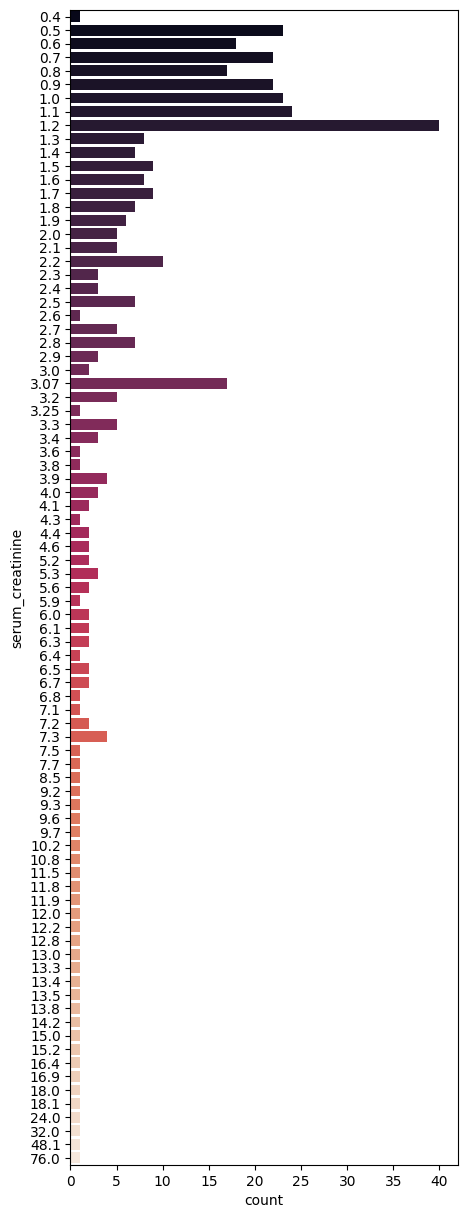

In [43]:
plt.figure(figsize=(5,15))
sns.countplot(df, y='serum_creatinine',palette='rocket')

<Axes: xlabel='sodium', ylabel='count'>

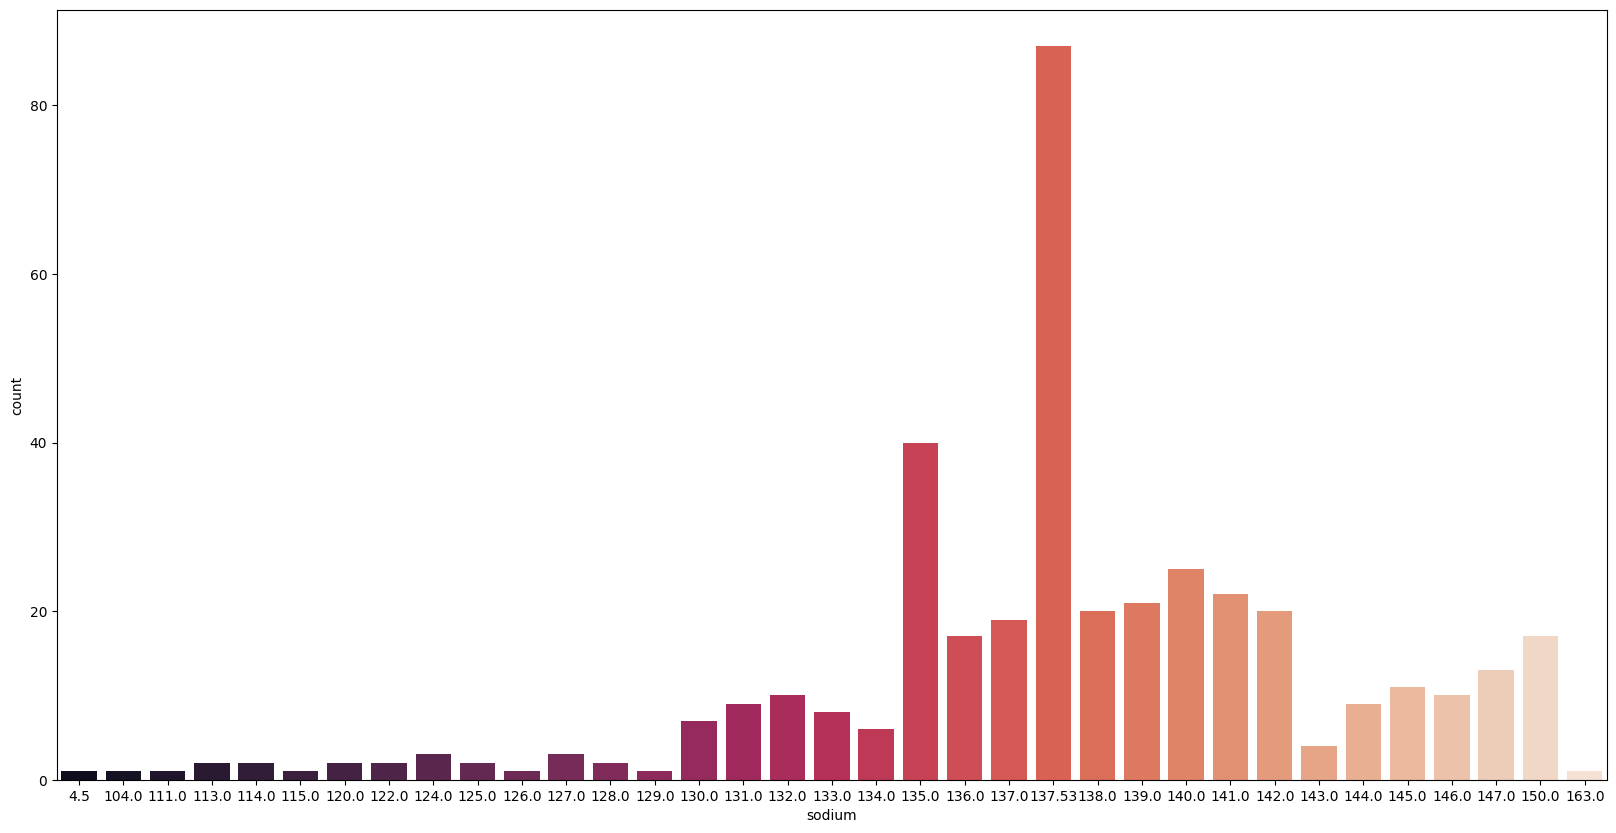

In [52]:
plt.figure(figsize=(20,10))
sns.countplot(df, x='sodium',palette='rocket')

<Axes: xlabel='potassium', ylabel='count'>

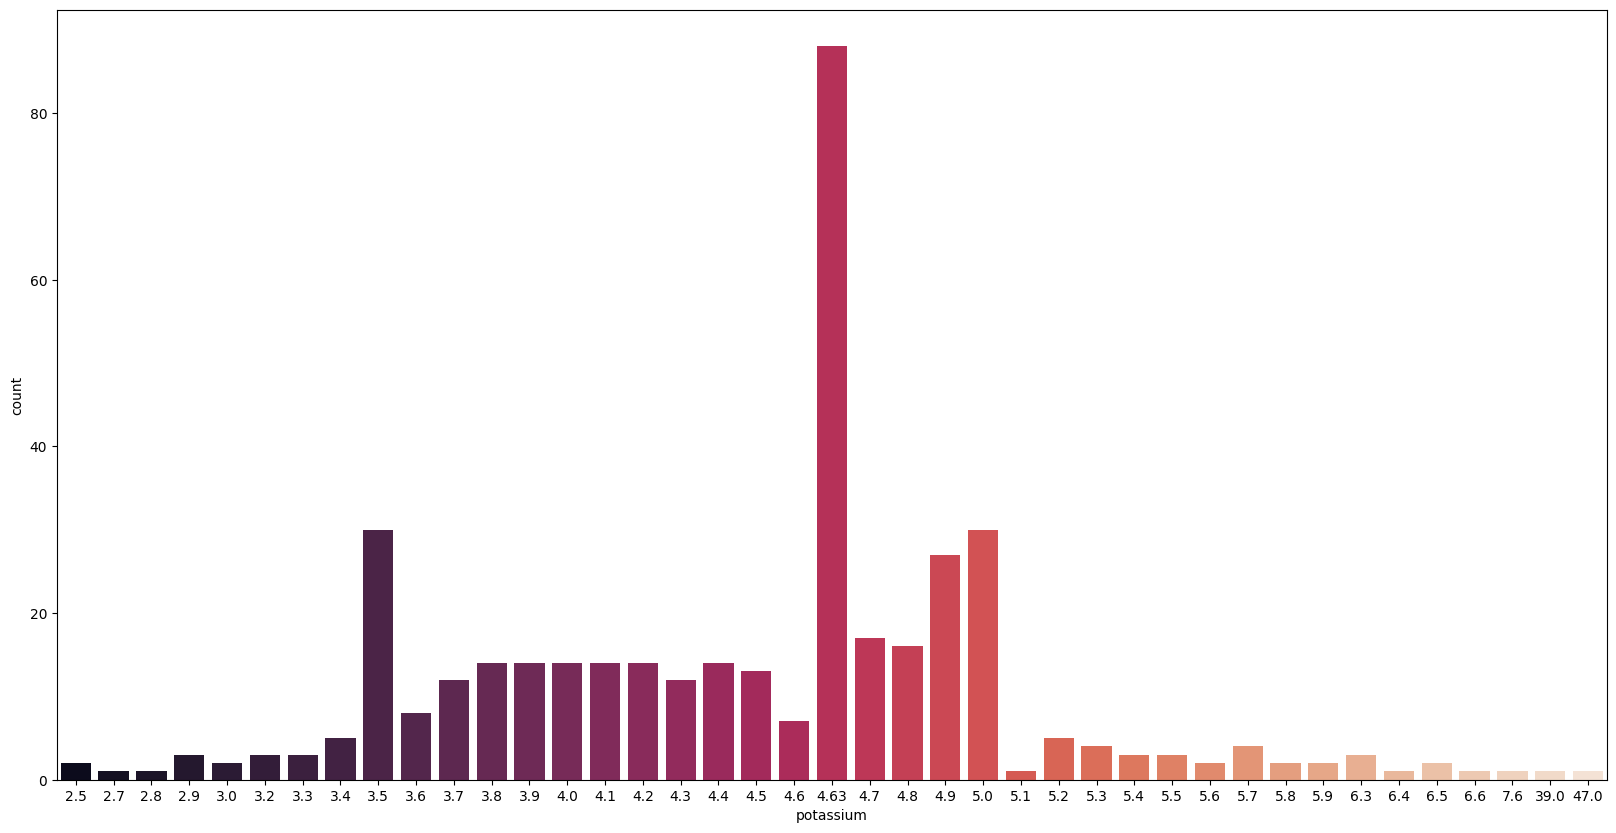

In [53]:
plt.figure(figsize=(20,10))
sns.countplot(df, x='potassium',palette='rocket')

<Axes: xlabel='count', ylabel='haemoglobin'>

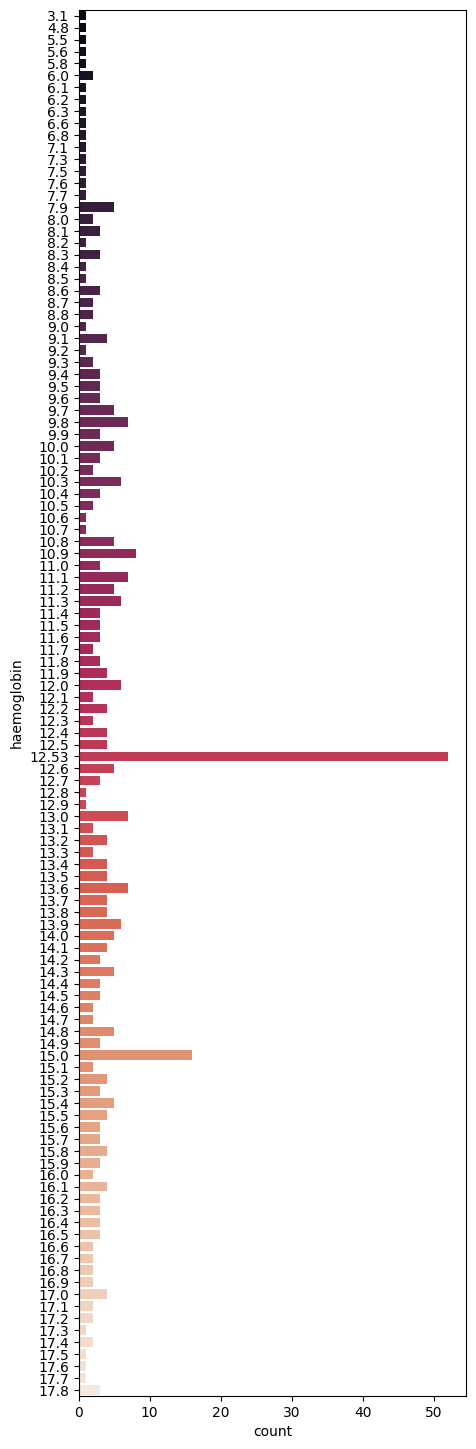

In [55]:
plt.figure(figsize=(5,18))
sns.countplot(df, y='haemoglobin',palette='rocket')

<Axes: xlabel='count', ylabel='white_blood_cell_count'>

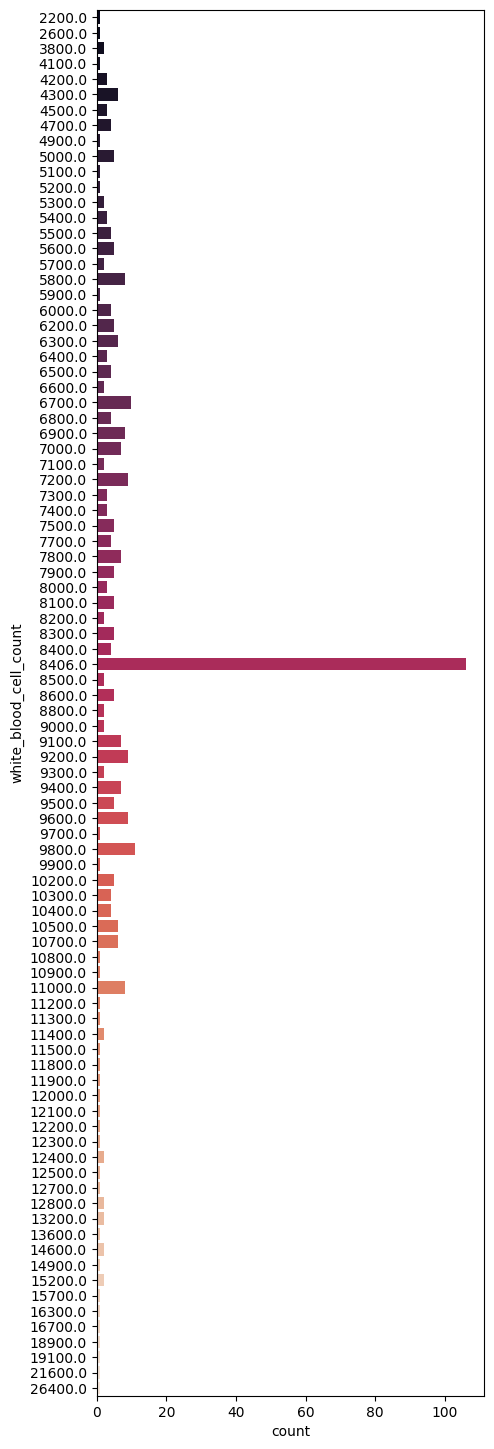

In [57]:
plt.figure(figsize=(5,18))
sns.countplot(df, y='white_blood_cell_count',palette='rocket')

<Axes: xlabel='count', ylabel='red_blood_cell_count'>

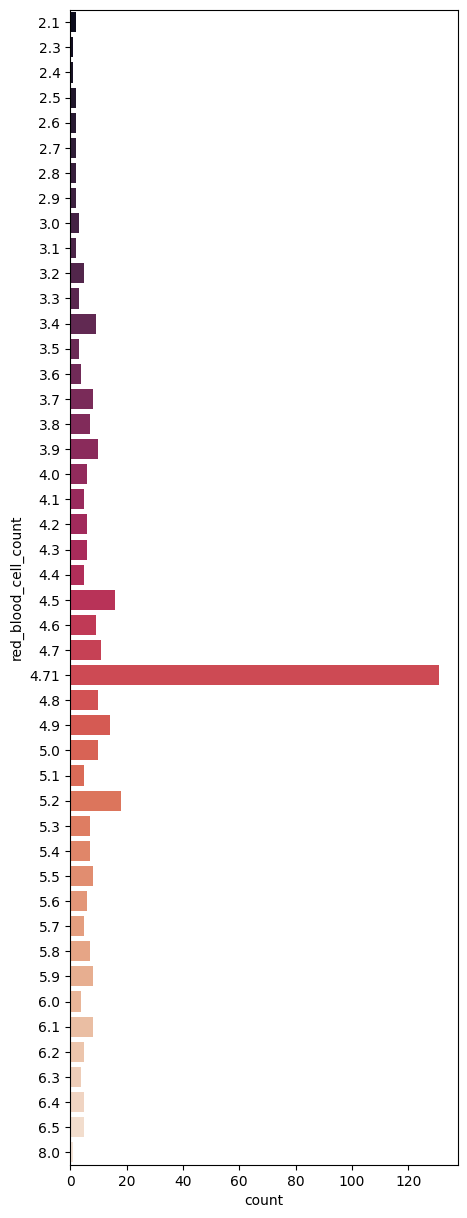

In [63]:
plt.figure(figsize=(5,15))
sns.countplot(df, y='red_blood_cell_count',palette='rocket')

<Axes: xlabel='hypertension', ylabel='count'>

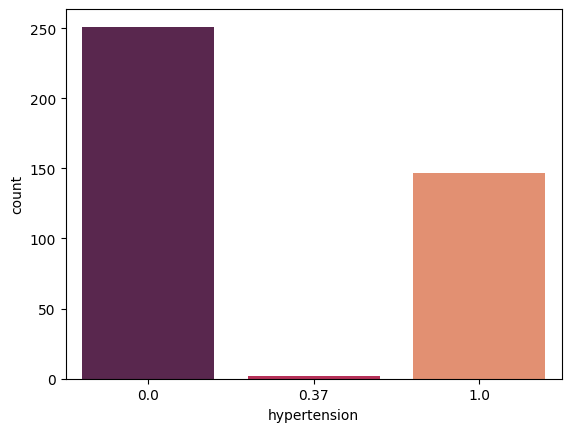

In [66]:
sns.countplot(df, x='hypertension',palette='rocket')

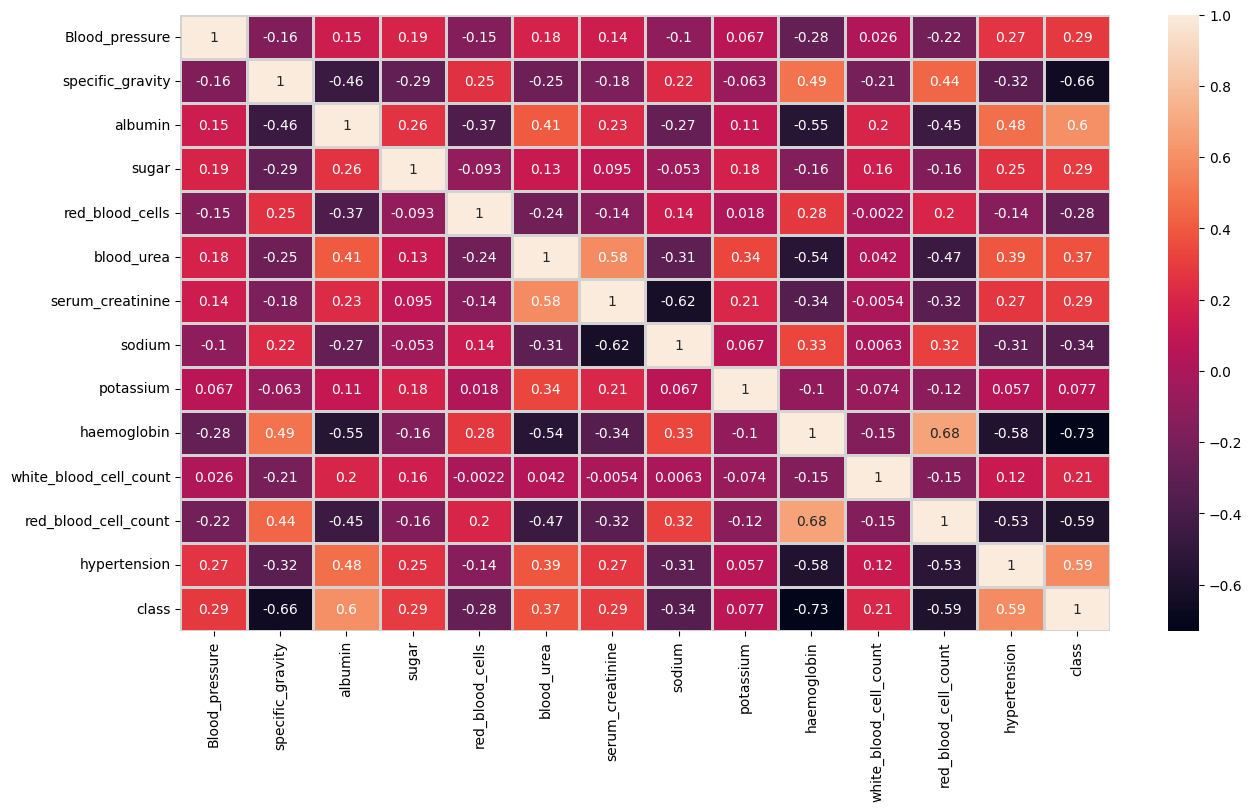

In [67]:
# heatmap of data

plt.figure(figsize = (15, 8))

sns.heatmap(df.corr(), annot = True, linewidths = 2, linecolor = 'lightgrey')
plt.show()

<h1>Exploratory Data Analysis (EDA)

In [68]:
# defining functions to create plot

def violin(col):
    fig = px.violin(df, y=col, x="class", color="class", box=True, template = 'plotly_dark')
    return fig.show()

def kde(col):
    grid = sns.FacetGrid(df, hue="class", height = 6, aspect=2)
    grid.map(sns.kdeplot, col)
    grid.add_legend()

def scatter(col1, col2):
    fig = px.scatter(df, x=col1, y=col2, color="class", template = 'plotly_dark')
    return fig.show()

In [70]:
for i in df.columns:
  print(f"The Violin Plot for {i}:")
  violin(i)

The Violin Plot for Blood_pressure


The Violin Plot for specific_gravity


The Violin Plot for albumin


The Violin Plot for sugar


The Violin Plot for red_blood_cells


...

The Violin Plot for haemoglobin


The Violin Plot for white_blood_cell_count


The Violin Plot for red_blood_cell_count


The Violin Plot for hypertension


The Violin Plot for class


The KDE Plot for Blood_pressure:
The KDE Plot for specific_gravity:
The KDE Plot for albumin:
The KDE Plot for sugar:
The KDE Plot for red_blood_cells:
The KDE Plot for blood_urea:
The KDE Plot for serum_creatinine:
The KDE Plot for sodium:
The KDE Plot for potassium:
The KDE Plot for haemoglobin:
The KDE Plot for white_blood_cell_count:
The KDE Plot for red_blood_cell_count:
The KDE Plot for hypertension:
The KDE Plot for class:


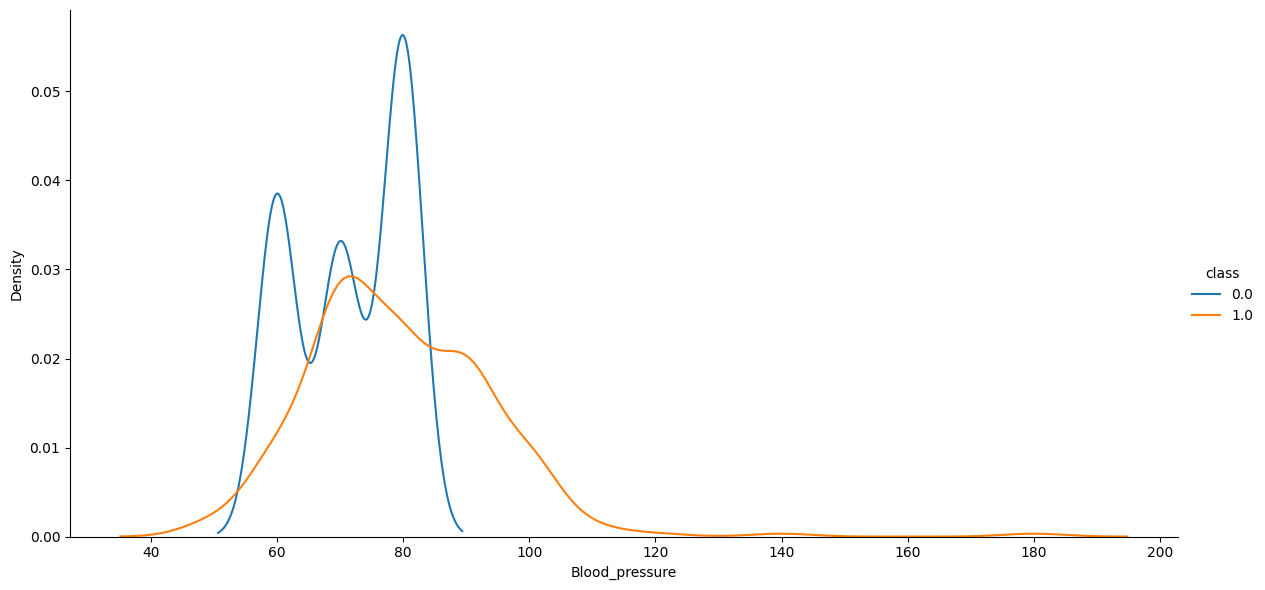

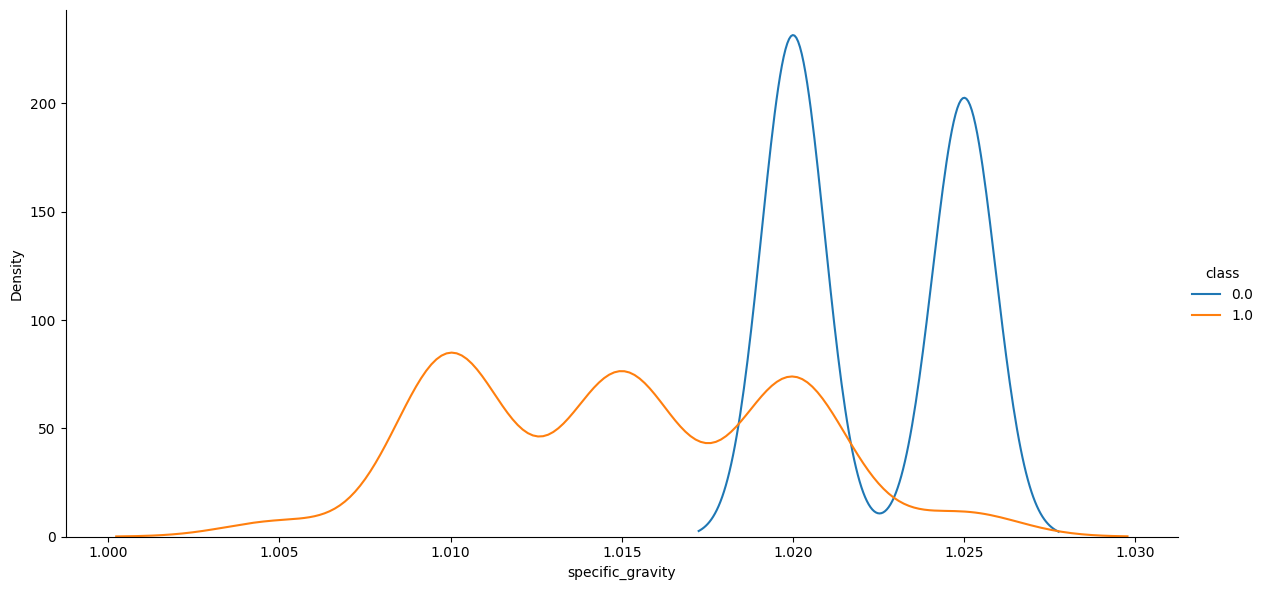

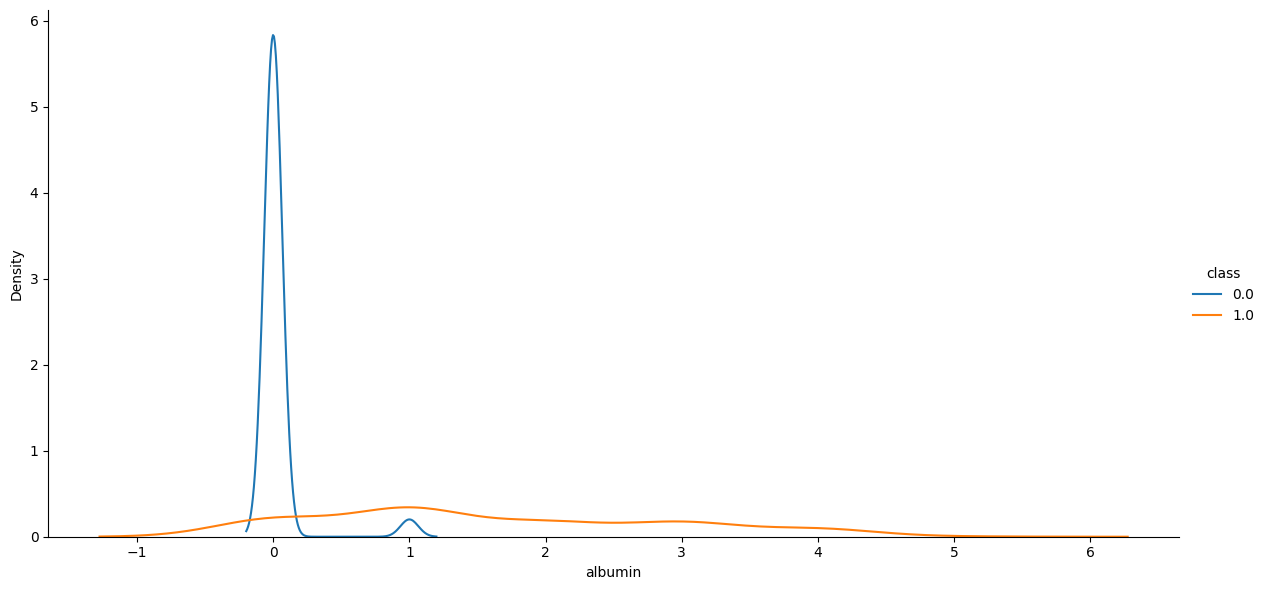

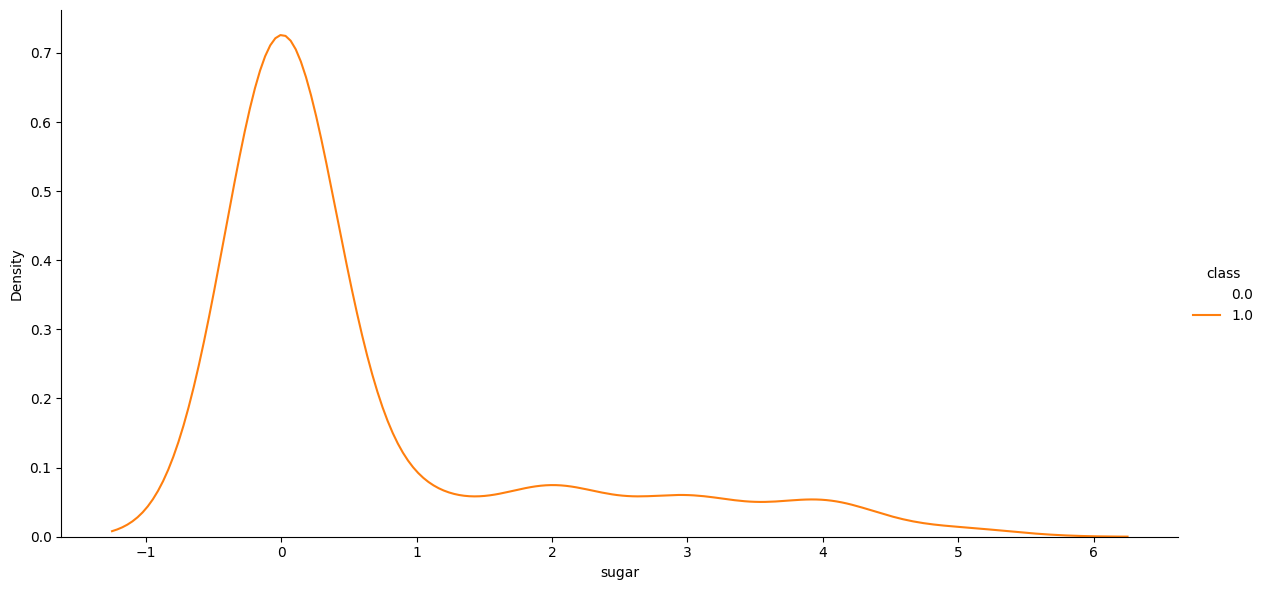

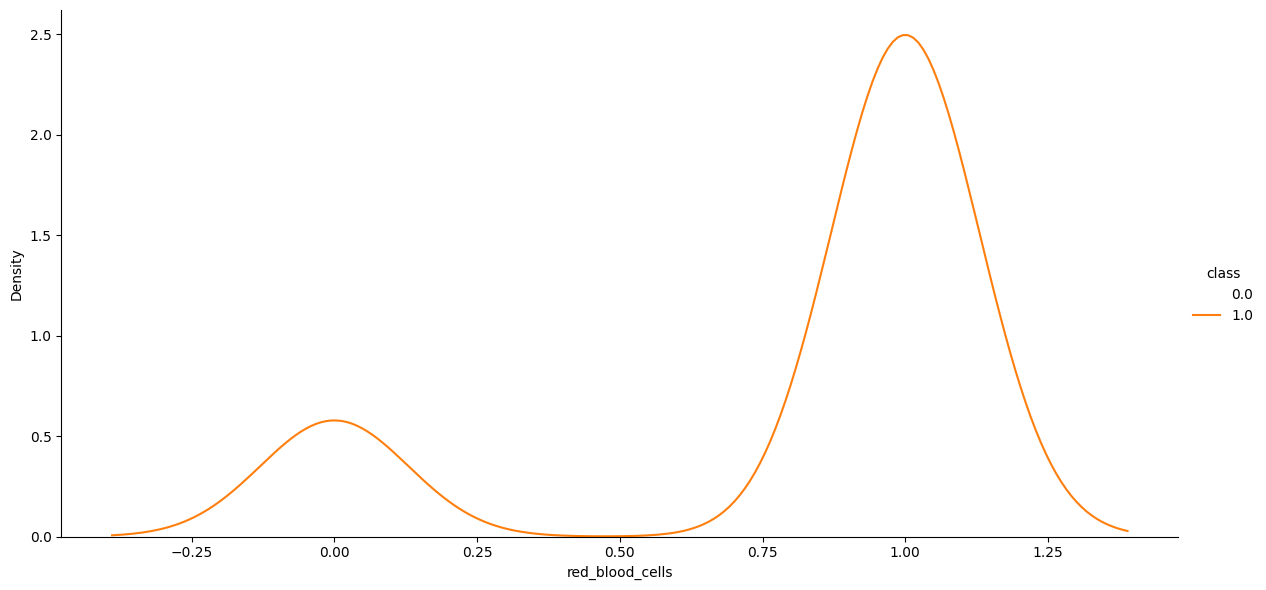

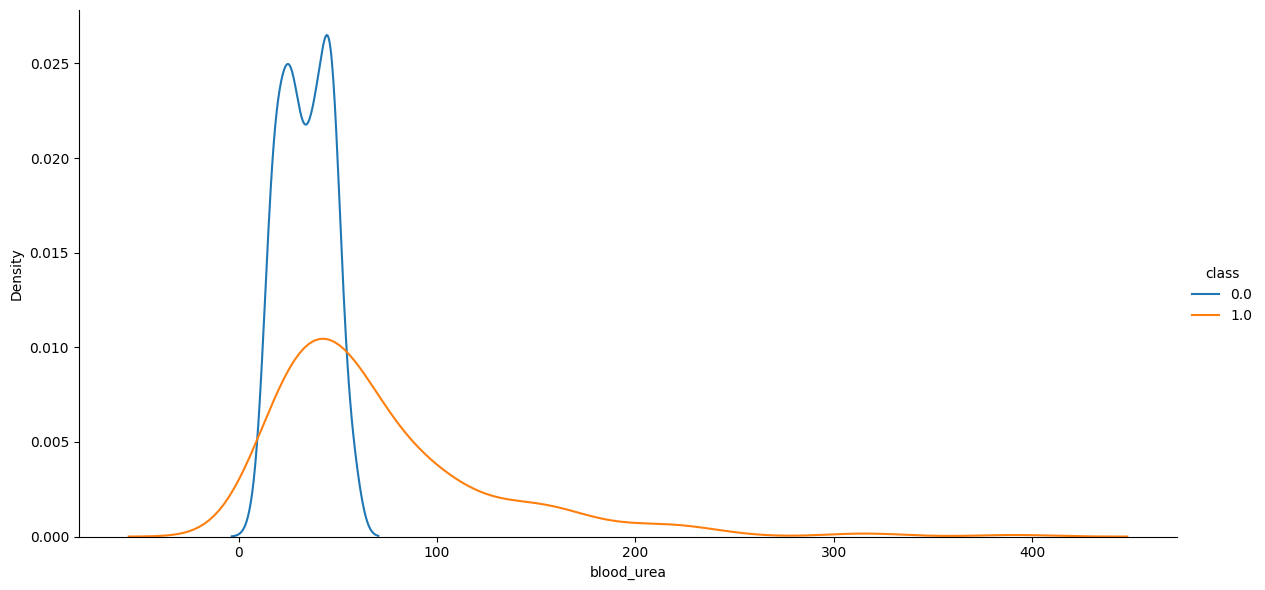

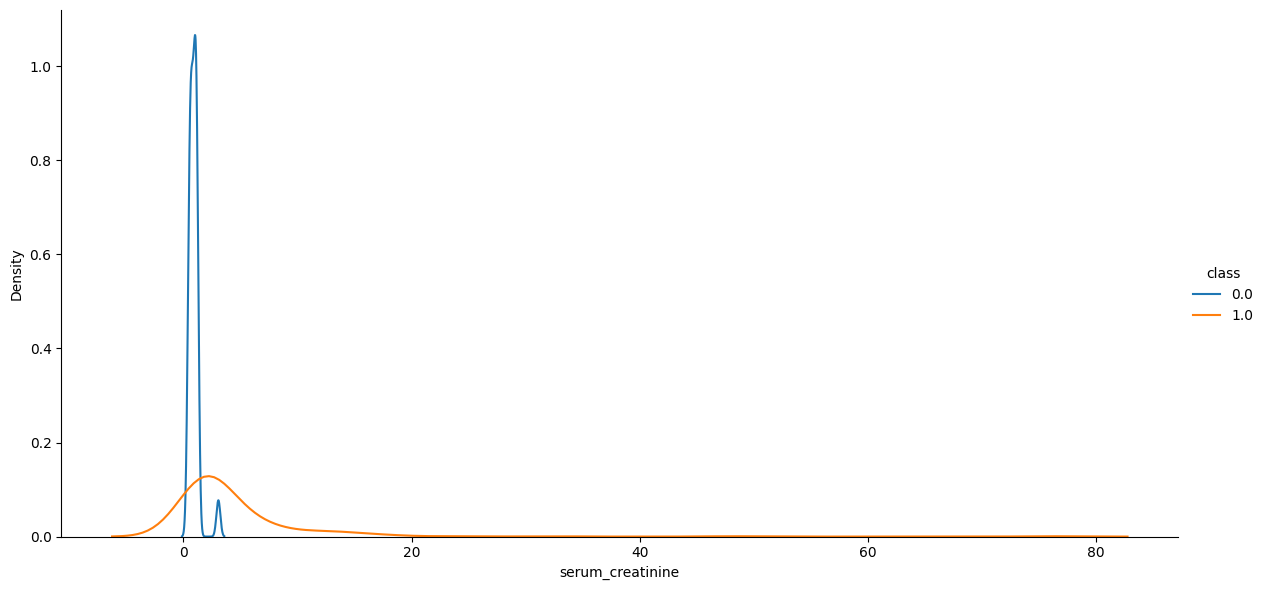

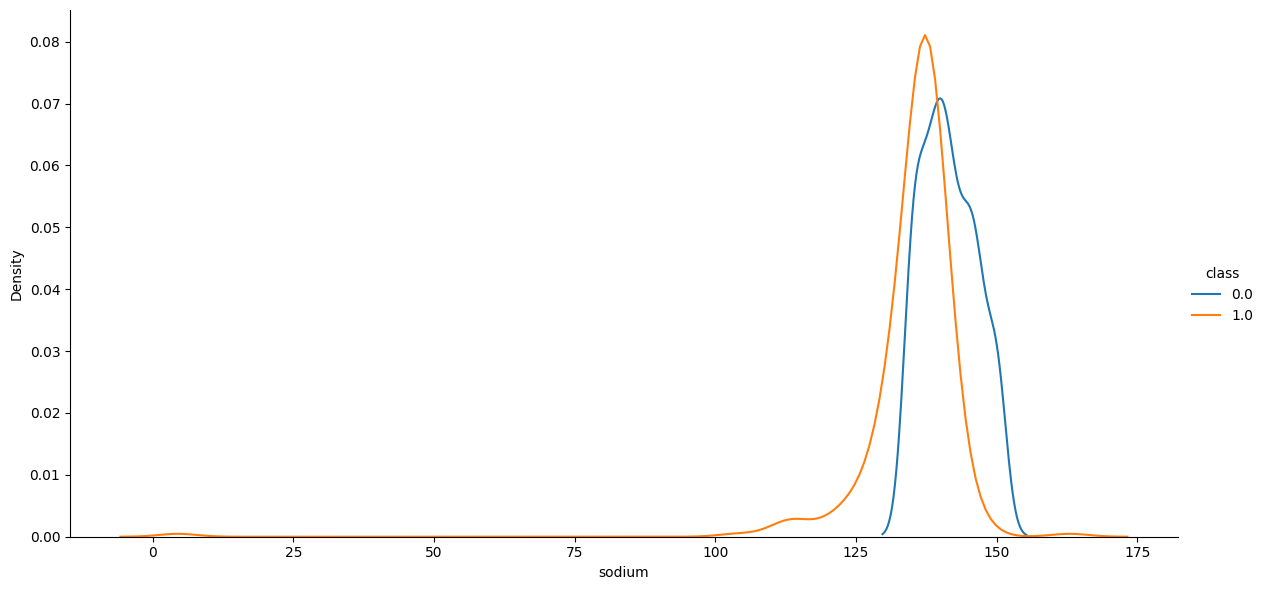

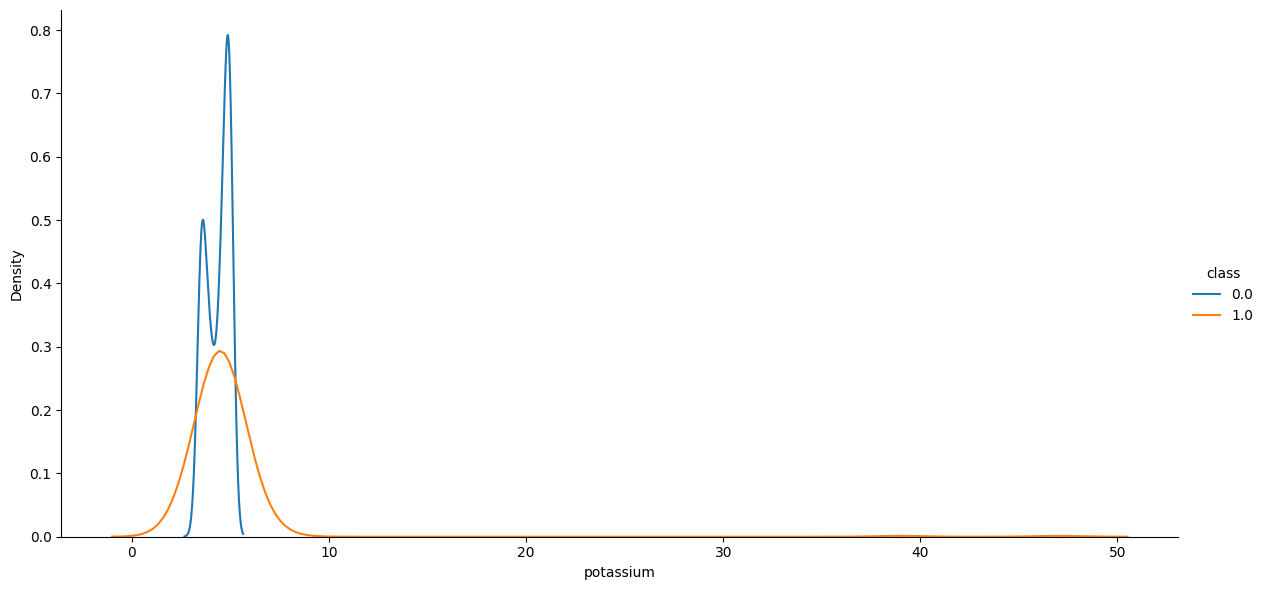

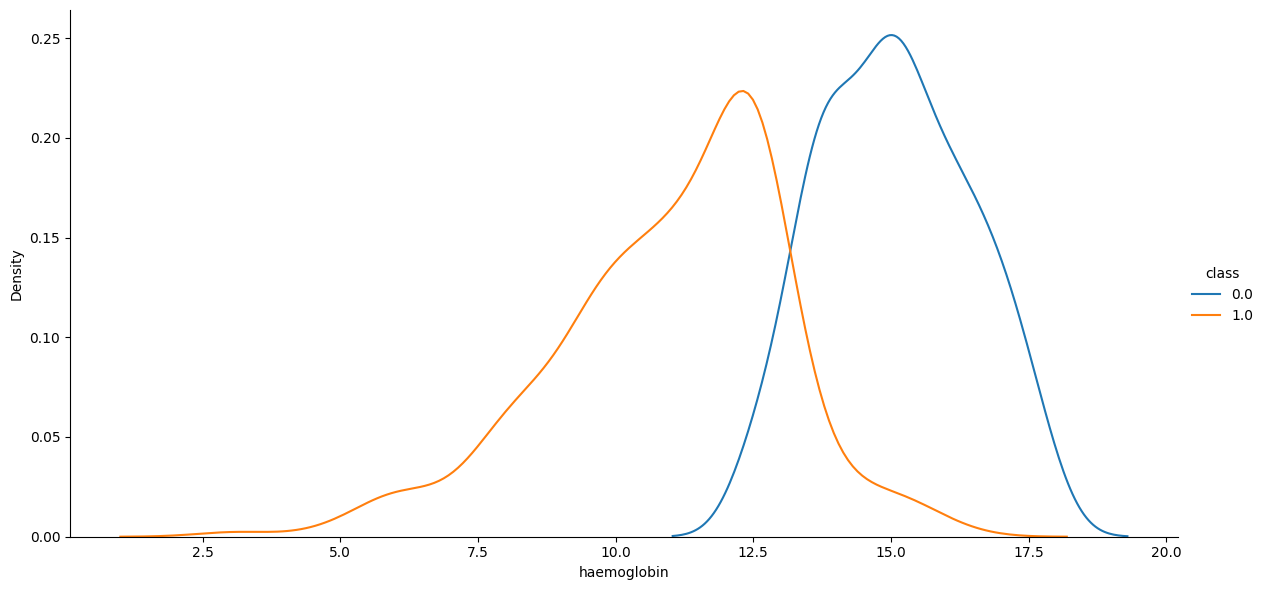

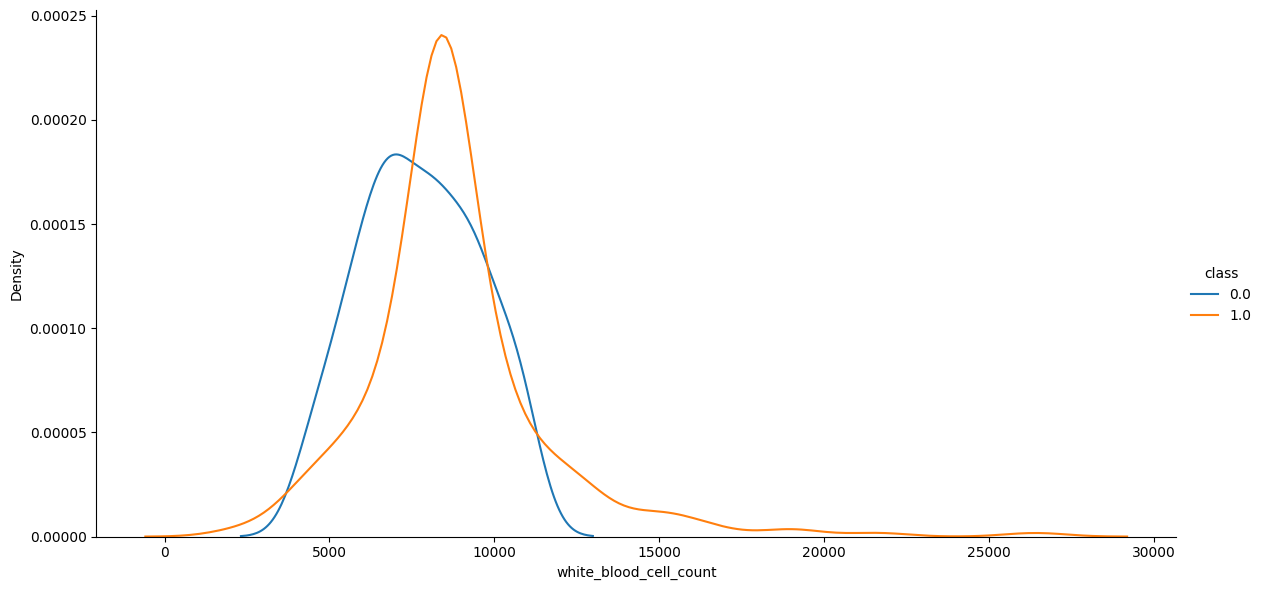

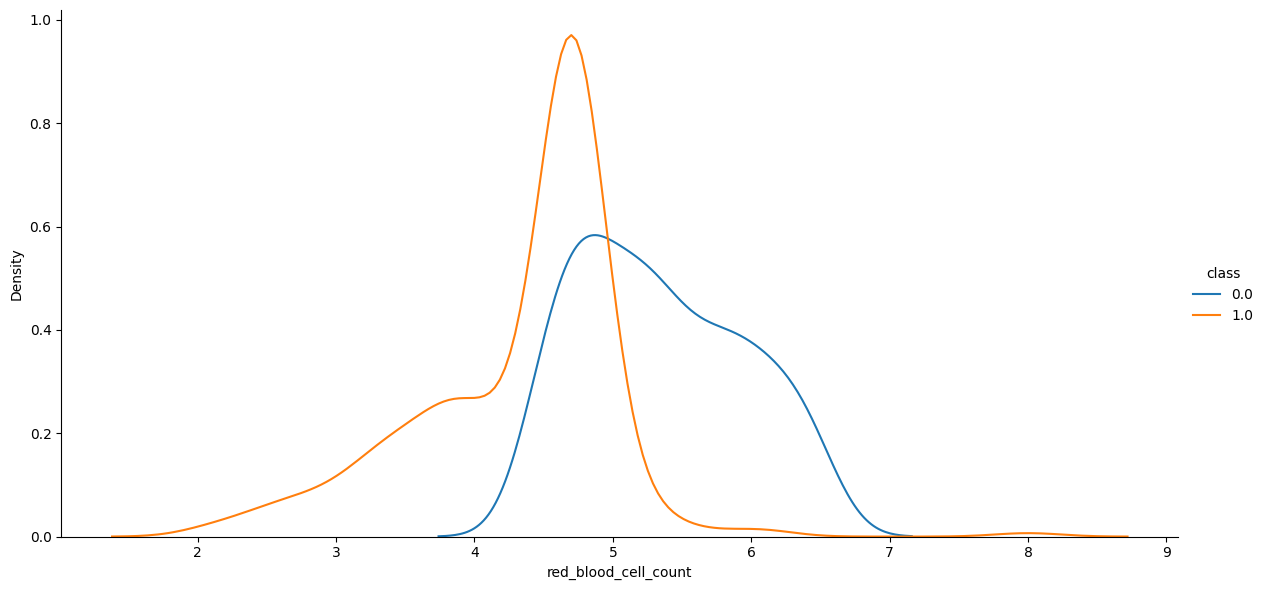

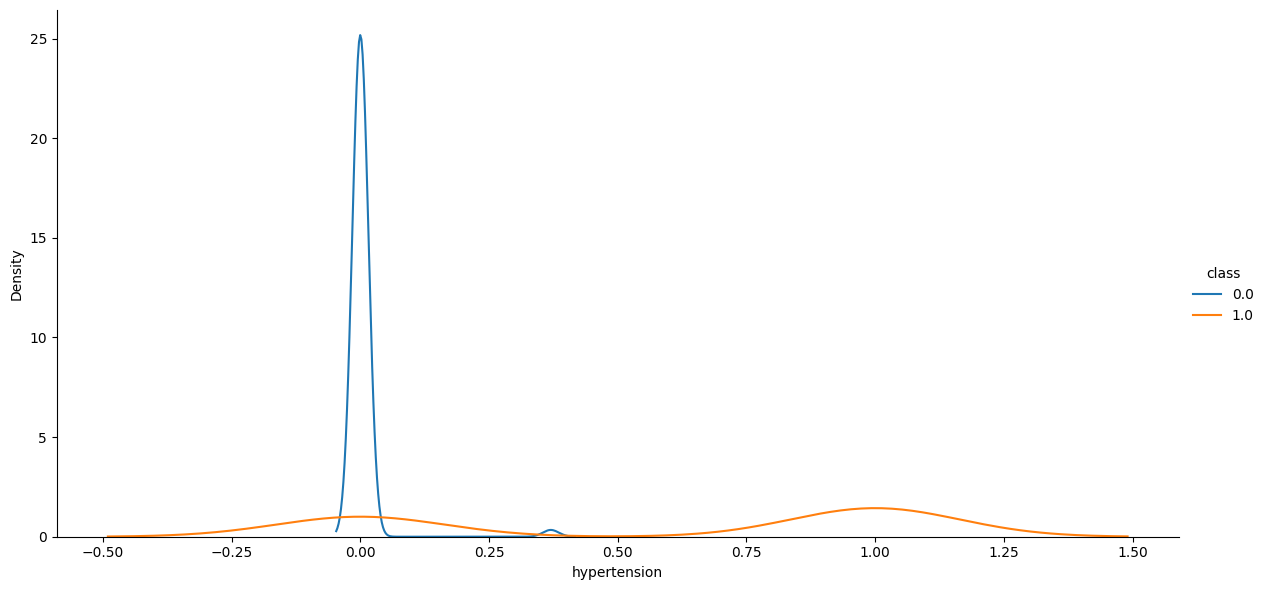

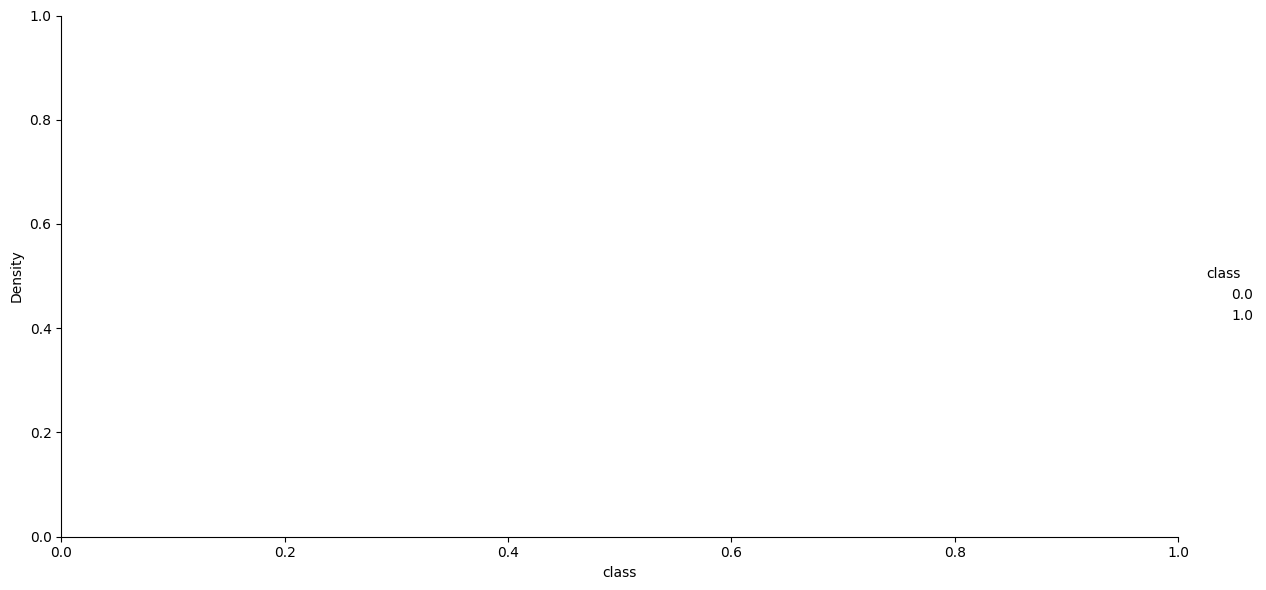

In [71]:
for i in df.columns:
  print(f"The KDE Plot for {i}:")
  kde(i)

In [72]:
scatter('red_blood_cell_count', 'albumin')

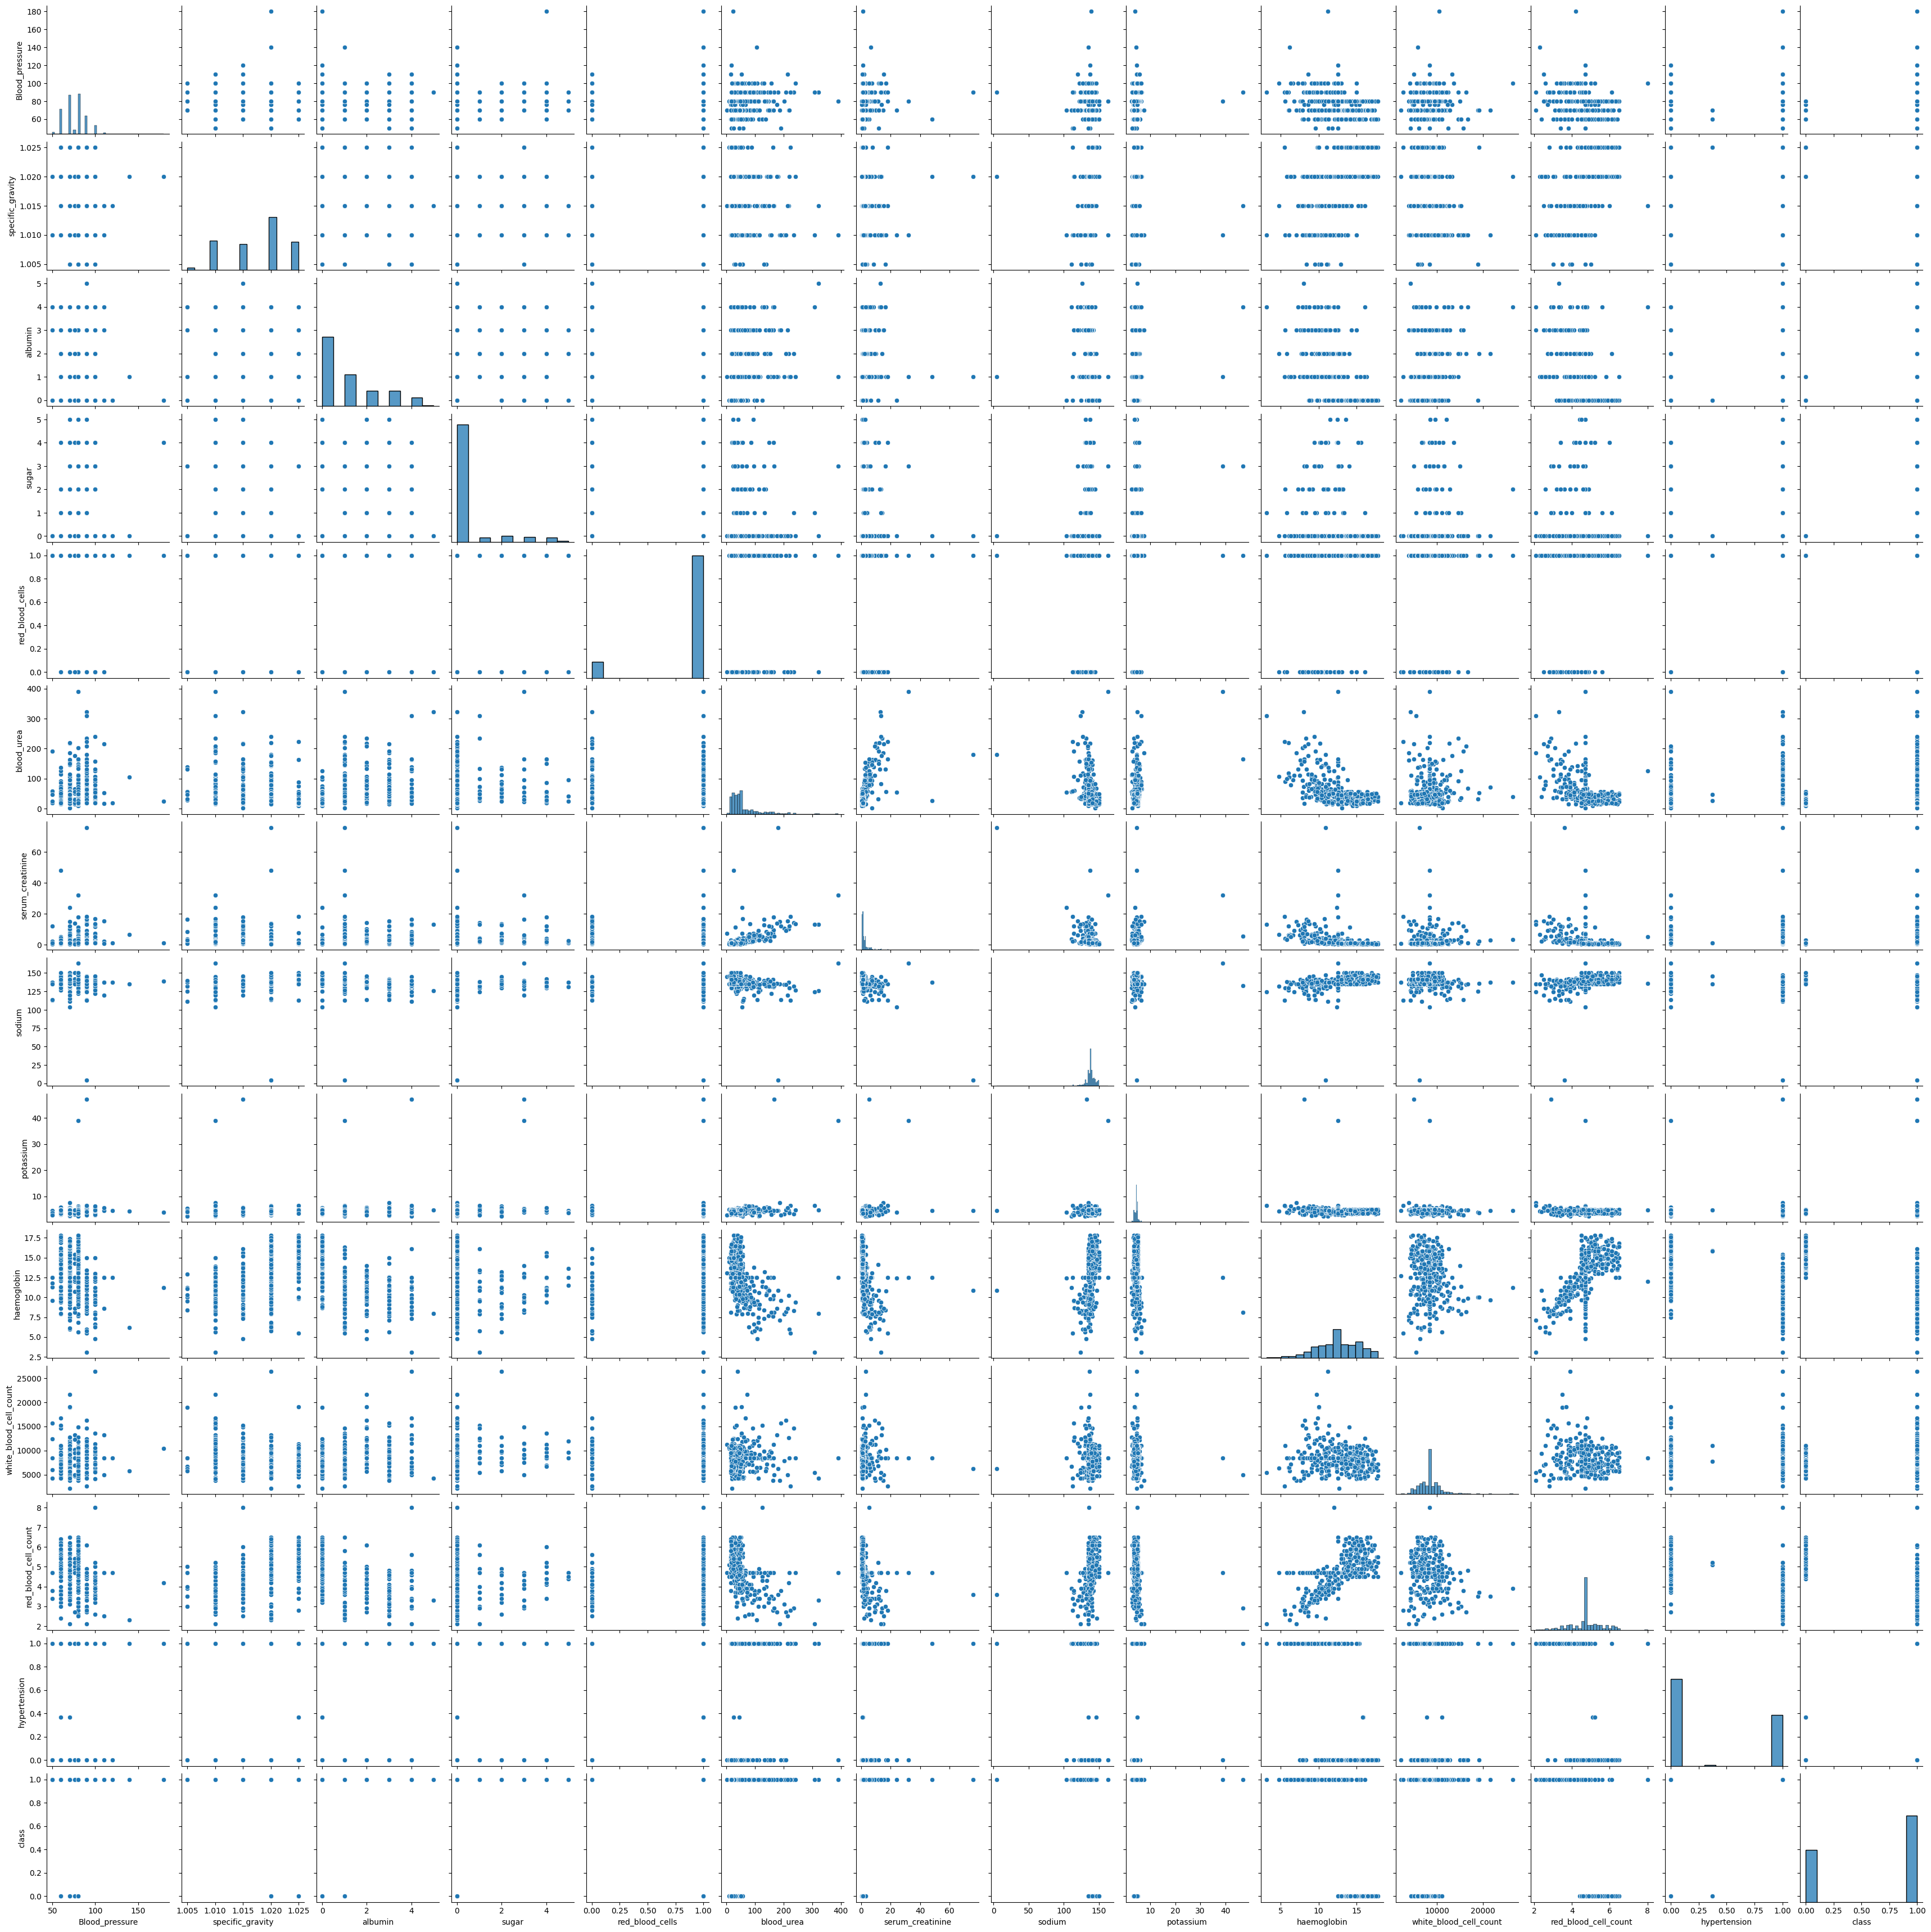

In [73]:
sns.pairplot(data=df)

In [75]:
px.bar(df, x="specific_gravity", y="albumin", color='class', barmode='group', template = 'plotly_dark', height = 400)

In [77]:
px.bar(df, x="Blood_pressure", y="haemoglobin", color='class', barmode='group', template = 'plotly_dark', height = 400)

In [74]:
df.columns

Index(['Blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'white_blood_cell_count',
       'red_blood_cell_count', 'hypertension', 'class'],
      dtype='object')

<h1>Data Pre Processing

In [78]:
# checking for null values

df.isna().sum().sort_values(ascending = False)

Blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
red_blood_cells           0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
haemoglobin               0
white_blood_cell_count    0
red_blood_cell_count      0
hypertension              0
class                     0
dtype: int64

</h1>Feature *Encoding*

In [79]:
for col in df.columns:
    print(f"{col} has {df[col].nunique()} categories\n")

Blood_pressure has 11 categories

specific_gravity has 5 categories

albumin has 6 categories

sugar has 6 categories

red_blood_cells has 2 categories

blood_urea has 118 categories

serum_creatinine has 85 categories

sodium has 35 categories

potassium has 41 categories

haemoglobin has 116 categories

white_blood_cell_count has 90 categories

red_blood_cell_count has 46 categories

hypertension has 3 categories

class has 2 categories



<h1> Finding Best accuracy Models to a dataset

In [81]:
pip install lazypredict

In [82]:

from lazypredict.Supervised import LazyClassifier

from sklearn.model_selection import train_test_split

X = data.data
y= data.target

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=.5,random_state =123)

clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)

models,predictions = clf.fit(X_train, X_test, y_train, y_test)
models

100%|██████████| 29/29 [00:01<00:00, 18.23it/s]

[LightGBM] [Info] Number of positive: 122, number of negative: 78
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000542 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 278
[LightGBM] [Info] Number of data points in the train set: 200, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.610000 -> initscore=0.447312
[LightGBM] [Info] Start training from score 0.447312
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
AdaBoostClassifier,0.99,1.00,1.00,1.00,0.15
ExtraTreesClassifier,0.99,1.00,1.00,1.00,0.14
LGBMClassifier,0.99,0.99,0.99,0.99,0.18
SVC,0.98,0.99,0.99,0.99,0.04
NuSVC,0.98,0.98,0.98,0.98,0.02
LogisticRegression,0.98,0.98,0.98,0.98,0.03
XGBClassifier,0.98,0.98,0.98,0.98,0.27
RandomForestClassifier,0.98,0.98,0.98,0.98,0.21
BaggingClassifier,0.98,0.98,0.98,0.98,0.04


# let us take few machine learning classifier models.

# Model Building

In [83]:
ind_col = [col for col in df.columns if col != 'class']
dep_col = 'class'

X = df[ind_col]
y = df[dep_col]

In [84]:
# splitting data intp training and test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 0)

# KNN

In [85]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of knn

knn_acc = accuracy_score(y_test, knn.predict(X_test))

print(f"Training Accuracy of KNN is {accuracy_score(y_train, knn.predict(X_train))}")
print(f"Test Accuracy of KNN is {knn_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, knn.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, knn.predict(X_test))}")

Training Accuracy of KNN is 0.7964285714285714
Test Accuracy of KNN is 0.6416666666666667 

Confusion Matrix :- 
[[29 19]
 [24 48]]

Classification Report :- 
               precision    recall  f1-score   support

         0.0       0.55      0.60      0.57        48
         1.0       0.72      0.67      0.69        72

    accuracy                           0.64       120
   macro avg       0.63      0.64      0.63       120
weighted avg       0.65      0.64      0.64       120



# Decision Tree Classifier

In [86]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of decision tree

dtc_acc = accuracy_score(y_test, dtc.predict(X_test))

print(f"Training Accuracy of Decision Tree Classifier is {accuracy_score(y_train, dtc.predict(X_train))}")
print(f"Test Accuracy of Decision Tree Classifier is {dtc_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, dtc.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, dtc.predict(X_test))}")

Training Accuracy of Decision Tree Classifier is 1.0
Test Accuracy of Decision Tree Classifier is 0.9833333333333333 

Confusion Matrix :- 
[[48  0]
 [ 2 70]]

Classification Report :- 
               precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        48
         1.0       1.00      0.97      0.99        72

    accuracy                           0.98       120
   macro avg       0.98      0.99      0.98       120
weighted avg       0.98      0.98      0.98       120



In [87]:
# hyper parameter tuning of decision tree

from sklearn.model_selection import GridSearchCV
grid_param = {
    'criterion' : ['gini', 'entropy'],
    'max_depth' : [3, 5, 7, 10],
    'splitter' : ['best', 'random'],
    'min_samples_leaf' : [1, 2, 3, 5, 7],
    'min_samples_split' : [1, 2, 3, 5, 7],
    'max_features' : ['auto', 'sqrt', 'log2']
}

grid_search_dtc = GridSearchCV(dtc, grid_param, cv = 5, n_jobs = -1, verbose = 1)
grid_search_dtc.fit(X_train, y_train)

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 3, 5, 7],
                         'min_samples_split': [1, 2, 3, 5, 7],
                         'splitter': ['best', 'random']},
             verbose=1)

In [88]:
# best parameters and best score

print(grid_search_dtc.best_params_)
print(grid_search_dtc.best_score_)

{'criterion': 'entropy', 'max_depth': 7, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 3, 'splitter': 'best'}
0.9892857142857142


In [89]:
# best estimator

dtc = grid_search_dtc.best_estimator_

# accuracy score, confusion matrix and classification report of decision tree

dtc_acc = accuracy_score(y_test, dtc.predict(X_test))

print(f"Training Accuracy of Decision Tree Classifier is {accuracy_score(y_train, dtc.predict(X_train))}")
print(f"Test Accuracy of Decision Tree Classifier is {dtc_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, dtc.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, dtc.predict(X_test))}")

Training Accuracy of Decision Tree Classifier is 0.9964285714285714
Test Accuracy of Decision Tree Classifier is 0.975 

Confusion Matrix :- 
[[46  2]
 [ 1 71]]

Classification Report :- 
               precision    recall  f1-score   support

         0.0       0.98      0.96      0.97        48
         1.0       0.97      0.99      0.98        72

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



# Random Forest Classifier

In [90]:
from sklearn.ensemble import RandomForestClassifier

rd_clf = RandomForestClassifier(criterion = 'entropy', max_depth = 11, max_features = 'auto', min_samples_leaf = 2, min_samples_split = 3, n_estimators = 130)
rd_clf.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of random forest

rd_clf_acc = accuracy_score(y_test, rd_clf.predict(X_test))

print(f"Training Accuracy of Random Forest Classifier is {accuracy_score(y_train, rd_clf.predict(X_train))}")
print(f"Test Accuracy of Random Forest Classifier is {rd_clf_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, rd_clf.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, rd_clf.predict(X_test))}")

Training Accuracy of Random Forest Classifier is 1.0
Test Accuracy of Random Forest Classifier is 1.0 

Confusion Matrix :- 
[[48  0]
 [ 0 72]]

Classification Report :- 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        48
         1.0       1.00      1.00      1.00        72

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



# Ada Boost Classifier

In [91]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(base_estimator = dtc)
ada.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of ada boost

ada_acc = accuracy_score(y_test, ada.predict(X_test))

print(f"Training Accuracy of Ada Boost Classifier is {accuracy_score(y_train, ada.predict(X_train))}")
print(f"Test Accuracy of Ada Boost Classifier is {ada_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, ada.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, ada.predict(X_test))}")

Training Accuracy of Ada Boost Classifier is 1.0
Test Accuracy of Ada Boost Classifier is 1.0 

Confusion Matrix :- 
[[48  0]
 [ 0 72]]

Classification Report :- 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        48
         1.0       1.00      1.00      1.00        72

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



# Gradient Boosting Classifier

In [92]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of gradient boosting classifier

gb_acc = accuracy_score(y_test, gb.predict(X_test))

print(f"Training Accuracy of Gradient Boosting Classifier is {accuracy_score(y_train, gb.predict(X_train))}")
print(f"Test Accuracy of Gradient Boosting Classifier is {gb_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, gb.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, gb.predict(X_test))}")

Training Accuracy of Gradient Boosting Classifier is 1.0
Test Accuracy of Gradient Boosting Classifier is 1.0 

Confusion Matrix :- 
[[48  0]
 [ 0 72]]

Classification Report :- 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        48
         1.0       1.00      1.00      1.00        72

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



# Stochastic Gradient Boosting (SGB)

In [93]:
sgb = GradientBoostingClassifier(max_depth = 4, subsample = 0.90, max_features = 0.75, n_estimators = 200)
sgb.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of stochastic gradient boosting classifier

sgb_acc = accuracy_score(y_test, sgb.predict(X_test))

print(f"Training Accuracy of Stochastic Gradient Boosting is {accuracy_score(y_train, sgb.predict(X_train))}")
print(f"Test Accuracy of Stochastic Gradient Boosting is {sgb_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, sgb.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, sgb.predict(X_test))}")

Training Accuracy of Stochastic Gradient Boosting is 1.0
Test Accuracy of Stochastic Gradient Boosting is 1.0 

Confusion Matrix :- 
[[48  0]
 [ 0 72]]

Classification Report :- 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        48
         1.0       1.00      1.00      1.00        72

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



#XgBoost

In [94]:
from xgboost import XGBClassifier

xgb = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.5, max_depth = 5, n_estimators = 150)
xgb.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of xgboost

xgb_acc = accuracy_score(y_test, xgb.predict(X_test))

print(f"Training Accuracy of XgBoost is {accuracy_score(y_train, xgb.predict(X_train))}")
print(f"Test Accuracy of XgBoost is {xgb_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, xgb.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, xgb.predict(X_test))}")

Training Accuracy of XgBoost is 1.0
Test Accuracy of XgBoost is 1.0 

Confusion Matrix :- 
[[48  0]
 [ 0 72]]

Classification Report :- 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        48
         1.0       1.00      1.00      1.00        72

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



# Extra Trees Classifier

In [95]:
from sklearn.ensemble import ExtraTreesClassifier

etc = ExtraTreesClassifier()
etc.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of extra trees classifier

etc_acc = accuracy_score(y_test, etc.predict(X_test))

print(f"Training Accuracy of Extra Trees Classifier is {accuracy_score(y_train, etc.predict(X_train))}")
print(f"Test Accuracy of Extra Trees Classifier is {etc_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, etc.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, etc.predict(X_test))}")

Training Accuracy of Extra Trees Classifier is 1.0
Test Accuracy of Extra Trees Classifier is 0.9916666666666667 

Confusion Matrix :- 
[[48  0]
 [ 1 71]]

Classification Report :- 
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99        48
         1.0       1.00      0.99      0.99        72

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



# Models Comparison

                          Model  Score
2      Random Forest Classifier   1.00
3          Ada Boost Classifier   1.00
4  Gradient Boosting Classifier   1.00
5  Stochastic Gradient Boosting   1.00
6                       XgBoost   1.00
7        Extra Trees Classifier   0.99
1      Decision Tree Classifier   0.97
0                           KNN   0.64


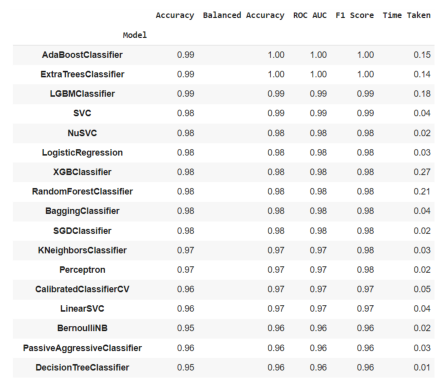

In [100]:
models = pd.DataFrame({
    'Model' : [ 'KNN', 'Decision Tree Classifier', 'Random Forest Classifier','Ada Boost Classifier','Gradient Boosting Classifier', 'Stochastic Gradient Boosting', 'XgBoost', 'Extra Trees Classifier'],
    'Score' : [knn_acc, dtc_acc, rd_clf_acc, ada_acc, gb_acc, sgb_acc, xgb_acc, etc_acc]
})

print(models.sort_values(by = 'Score', ascending = False))
import matplotlib.image as mpimg

img = mpimg.imread('/content/Screenshot 2024-01-08 152247.png') #Replace "image.jpg" with the path of your image
plt.imshow(img)
plt.axis('off')
plt.show()

In [97]:
px.bar(data_frame = models, x = 'Score', y = 'Model', color = 'Score', template = 'plotly_dark',title = 'Models Comparison')